In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px
import seaborn as sns
import os
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [8]:
# List all CSV files in the 'datathon-2026-round-1' directory
csv_dir = 'datathon-2026-round-1'
csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]

# Load each CSV file into a dataframe with variable name as the file name (without .csv)
for file in csv_files:
    var_name = os.path.splitext(file)[0]
    df = pd.read_csv(os.path.join(csv_dir, file))
    globals()[var_name] = df

/tmp/ipykernel_158743/2926216130.py:8: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(csv_dir, file))


## Phần 1 - Trả lời câu hỏi

In [30]:
#Q1 
# orders = orders[orders['order_status'] == '']
multi_order = orders['customer_id'].value_counts()
multi_order = multi_order[multi_order > 1].index

orders_multi = orders[orders['customer_id'].isin(multi_order)].copy()

orders_multi['order_date'] = pd.to_datetime(orders_multi['order_date'])

orders_multi = orders_multi.sort_values(['customer_id', 'order_date'])

orders_multi['inter_order_gap'] = orders_multi.groupby('customer_id')['order_date'].diff().dt.days

median_gap = orders_multi['inter_order_gap'].median()
print(f"{median_gap:.0f}")

# Answer: 144

144


In [31]:
#Q2
products['gross_margin'] = (products['price'] - products['cogs']) / products['price']

segment_margin = products.groupby('segment')['gross_margin'].mean().sort_values(ascending=False)

top_segment = segment_margin.idxmax()
top_margin = segment_margin.max()
print(f"Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: {top_segment} ({top_margin:.2%})")
print(segment_margin)
# Answer: Standard
# print(80*'-')
# category_margin = products.groupby('category')['gross_margin'].mean().sort_values(ascending=False)

# top_segment = category_margin.idxmax()
# top_margin = category_margin.max()
# print(f"Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: {top_segment} ({top_margin:.2%})")
# print(category_margin)

Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: Standard (31.34%)
segment
Standard       0.313442
Premium        0.285377
All-weather    0.284176
Activewear     0.265600
Performance    0.263650
Balanced       0.258038
Trendy         0.240758
Everyday       0.236343
Name: gross_margin, dtype: float64


In [32]:
#Q3
returns_streetwear = returns.merge(products[['product_id', 'category']], on='product_id')

returns_streetwear = returns_streetwear[returns_streetwear['category'] == 'Streetwear']
most_common_reason = returns_streetwear['return_reason'].value_counts().idxmax()
print("Lý do trả hàng nhiều nhất cho Streetwear:", most_common_reason)
print(returns_streetwear['return_reason'].value_counts())
# Answer: wrong_size

Lý do trả hàng nhiều nhất cho Streetwear: wrong_size
return_reason
wrong_size          7626
defective           4330
not_as_described    3854
changed_mind        3830
late_delivery       2159
Name: count, dtype: int64


In [33]:
#Q4
avg_bounce_by_source = web_traffic.groupby('traffic_source')['bounce_rate'].mean().sort_values()
lowest_bounce_source = avg_bounce_by_source.idxmin()
lowest_bounce_value = avg_bounce_by_source.min()
print(f"Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất: {lowest_bounce_source} ({lowest_bounce_value:.5f})")
avg_bounce_by_source
#Answer: email_campaign

Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất: email_campaign (0.00446)


traffic_source
email_campaign    0.004458
social_media      0.004476
paid_search       0.004478
referral          0.004499
organic_search    0.004504
direct            0.004511
Name: bounce_rate, dtype: float64

In [34]:
#Q5
promo_applied_pct = order_items['promo_id'].notnull().mean() * 100
print(f"Tỷ lệ dòng áp dụng khuyến mãi: {promo_applied_pct:.2f}%")
#Answer: 39%

Tỷ lệ dòng áp dụng khuyến mãi: 38.66%


In [35]:
#Q6
valid_customers = customers[customers['age_group'].notnull()]

orders_per_customer = orders['customer_id'].value_counts()

valid_customers = valid_customers.copy()
valid_customers['order_count'] = valid_customers['customer_id'].map(orders_per_customer).fillna(0)

avg_orders_by_age = valid_customers.groupby('age_group')['order_count'].mean().sort_values(ascending=False)

top_age_group = avg_orders_by_age.idxmax()
top_avg_orders = avg_orders_by_age.max()
print(f"Nhóm tuổi có số đơn hàng trung bình trên mỗi khách hàng cao nhất: {top_age_group} ({top_avg_orders:.2f})")
avg_orders_by_age

# Answer: 55+

Nhóm tuổi có số đơn hàng trung bình trên mỗi khách hàng cao nhất: 55+ (5.41)


age_group
55+      5.406851
45-54    5.357241
35-44    5.337343
25-34    5.245226
18-24    5.226656
Name: order_count, dtype: float64

In [36]:
#Q7
sales_geo = order_items[["order_id", "unit_price", "quantity"]].copy()
sales_geo["sales"] = sales_geo["unit_price"] * sales_geo["quantity"]

# merge tables
sales_geo = sales_geo.merge(orders[["order_id", "zip"]], on="order_id", how="left")
sales_geo = sales_geo.merge(geography[["zip", "region"]], on="zip", how="left")
# sales_geo['city'] = sales_geo['city'].apply(no_accent_vietnamese).str.lower().str.strip().str.replace('tp. ', '').str.replace(' ', '').str.replace('thành phố ', '').str.replace('-', '').str.replace('city','')

# Calculate total sales by city
city_sales = sales_geo.groupby('region')['sales'].sum().reset_index()
city_sales.sort_values('sales', ascending=False)

# Answer: East

,region,sales
1,East,7.637533e+09
0,Central,4.941908e+09
2,West,3.851035e+09


In [37]:
#Q8
cancel_status = orders[orders['order_status'] == 'cancelled']
payment_method_counts = cancel_status['payment_method'].value_counts()
payment_method_counts

# Answer: credit card

payment_method
credit_card      28452
cod              15468
paypal            7817
apple_pay         5190
bank_transfer     2535
Name: count, dtype: int64

In [38]:
# Q9
total_sold_by_size = order_items.merge(products[['product_id', 'size']], on='product_id')
total_sold_by_size = total_sold_by_size.groupby('size')['quantity'].sum()

returns_with_size = returns.merge(products[['product_id', 'size']], on='product_id')
total_returned_by_size = returns_with_size.groupby('size')['return_id'].count()

return_rate_by_size = (total_returned_by_size / total_sold_by_size * 100).fillna(0).sort_values(ascending=False)

for size, rate in return_rate_by_size.items():
    print(f"Size {size}: {rate:.2f}% sản phẩm bị trả hàng")

top_size = return_rate_by_size.idxmax()
print(f"Size có tỷ lệ trả hàng cao nhất: {top_size}")

# Answer: Size XL

Size S: 1.26% sản phẩm bị trả hàng
Size L: 1.25% sản phẩm bị trả hàng
Size M: 1.24% sản phẩm bị trả hàng
Size XL: 1.23% sản phẩm bị trả hàng
Size có tỷ lệ trả hàng cao nhất: S


In [39]:
# Q10
payments_installments = payments[payments['installments'] > 0]
avg_payment_by_plan = payments_installments.groupby('installments')['payment_value'].mean().sort_values(ascending=False)

top_plan = avg_payment_by_plan.idxmax()
top_value = avg_payment_by_plan.max()
print(f"Kế hoạch trả góp có giá trị thanh toán trung bình trên mỗi đơn hàng cao nhất: {top_plan} kỳ ({top_value:,.2f})")
avg_payment_by_plan
# Answer: 6

Kế hoạch trả góp có giá trị thanh toán trung bình trên mỗi đơn hàng cao nhất: 6 kỳ (24,446.65)


installments
6     24446.654403
3     24399.635486
12    24245.772694
1     24113.274166
2       708.473729
Name: payment_value, dtype: float64

## Phần 2 - Đưa ra business insight và EDA

In [40]:
age_group_counts = customers['age_group'].value_counts().sort_index()
age_group_weights = age_group_counts / age_group_counts.sum() * 100# Tính trọng số (tỷ lệ %) cho từng nhóm tuổi

age_group_df = pd.DataFrame({
    'age_group': age_group_counts.index,
    'count': age_group_counts.values,
    'weight': age_group_weights.round(2).values
})

fig = px.bar(
    age_group_df,
    x='age_group',
    y='count',
    labels={'age_group': 'Nhóm tuổi', 'count': 'Số lượng khách hàng'},
    title='Phân bổ khách hàng theo nhóm tuổi',
    custom_data=['count', 'weight'],
    color='count',
    color_continuous_scale='Blues'
)
fig.update_traces(
    hovertemplate='Nhóm tuổi: %{x}<br>Số lượng khách: %{customdata[0]}<br>Trọng số: %{customdata[1]}%'
)
fig.update_layout(showlegend=False)
fig.show()

In [41]:
# reviews = reviews[["product_id", "order_id", "review_date", "rating", "review_title"]]                          # (*)
# order_items = order_items[["product_id", "quantity","discount_amount", "unit_price", "promo_id"]]               # quantity, unit_price, 
# products = products[["product_id", "category", "segment", "price", "cogs", "size"]]                             # category, segment, size, price, cogs
# inventory = inventory[["snapshot_date", "product_id", "stock_on_hand", "units_sold", "units_received", "stockout_days", ]]       # stock_on_hand, units_received, units_sold, stockout_days, sell_through_rate
# orders = orders[["order_id", "order_date", "customer_id", "order_status", "payment_method", "order_source"]]    # order_status, payment_method, order_source

<b>Góc 1: Gross Margin theo Category/Segment qua thời gian</b>

- Join <code>order_items</code> + <code>products</code> → tính <code>(unit_price - cogs) / unit_price</code> theo từng segment/category theo tháng

- Diagnostic: segment nào margin co lại, phải chăng do discount quá nhiều?

- Prescriptive: tối ưu discount policy cho từng segment


<b>Góc 2: Return Rate × Rating — vòng lặp chất lượng sản phẩm</b>

- Join <code>returns</code> + <code>reviews</code> + <code>products</code> theo <code>product_id</code>

- Sản phẩm có return rate cao có rating thấp không? Return reason nào gây mất doanh thu nhất?

- Prescriptive: ưu tiên cải thiện size guide (nếu <code>wrong_size</code> chiếm đa số)

 
Góc 3: Inventory health vs actual demand
- `inventory` có `stockout_flag`, `overstock_flag`, `days_of_supply`
- Cross với `order_items` để thấy revenue bị mất do hết hàng (`stockout_days`)
- Prescriptive: reorder policy theo category dựa trên `days_of_supply`

Góc 4: Order cohort & repeat purchase
- `orders` → cohort theo `order_date` month, xem retention
- Diagnostic: tháng nào có spike đơn hàng (TET, Black Friday)?
- Predictive: leading indicator cho revenue tháng tới

Góc 5: Revenue Leakage — Tiền đang chảy đi đâu?
**Câu hỏi kinh doanh:** Doanh thu thực tế bị mất bao nhiêu, do đâu?

**Mạch phân tích:**
- `order_items` → tính tổng `discount_amount` theo tháng → discount chiếm bao nhiêu % revenue gốc?
- Join với `promotions` → promotion nào tốn chi phí discount nhiều nhất nhưng không tăng quantity?
- Join với `returns` → refund_amount theo category → category nào có net revenue thấp nhất sau khi trừ return?
- **Prescriptive:** Cắt giảm promotion nào? Category nào cần cải thiện chất lượng?


Góc 6: Product Quality Loop — Vòng lặp chất lượng
**Câu hỏi kinh doanh:** Sản phẩm nào đang hại brand?

**Mạch phân tích:**
- Join `reviews` + `returns` + `products` theo `product_id`
- Cross `return_reason` với `rating` → sản phẩm rating thấp có return rate cao không?
- Segment nào (`Premium` vs `Standard`) có gap lớn nhất giữa kỳ vọng (price) và thực tế (rating)?
- `wrong_size` vs `defective` vs `changed_mind` → lý do nào controllable?
- **Prescriptive:** Đầu tư vào size guide, QC, hay product description?


Góc 7: Customer Purchase Pattern — Ai mua, mua khi nào?
**Câu hỏi kinh doanh:** Khi nào nên đẩy marketing/promotion?

**Mạch phân tích:**
- `orders` → aggregate theo tháng/quý → seasonality rõ không? (Tết, 11/11, Black Friday)
- `order_items` join `products` → category nào bán chạy theo mùa?
- `orders.order_source` + `orders.device_type` → channel nào convert tốt nhất?
- Cohort analysis: khách mua lần đầu tháng nào có retention cao nhất?
- **Prescriptive:** Lịch promotion tối ưu theo mùa + channel allocation

In [42]:
orders['order_source']

0            paid_search
1            paid_search
2                 direct
3               referral
4         email_campaign
               ...      
646940    email_campaign
646941          referral
646942    email_campaign
646943            direct
646944    organic_search
Name: order_source, Length: 646945, dtype: str

In [ ]:
# chi phí vốn + revenue + gross profit
# loại sản phẩm lỗ + tồn kho nhất
#! discount
# predictive(ứ đọng vốn, lỗ bao %)
# đề xuất sản phẩm (lượng nhập/discount , pick sp lãi nhiều hơn, biên lợi nhuận tốt hơn,...)

In [ ]:
cost_capital = products.merge(inventory[["product_id","snapshot_date","stock_on_hand", "units_received"]], on="product_id", how="left")

cost_capital['cost_capital'] = cost_capital['cogs'] * cost_capital['units_received']

cost_capital = cost_capital.sort_values('snapshot_date').reset_index()

revenue = order_items.merge(orders[["order_id", "order_date"]], on="order_id", how="left")

In [11]:
revenuee =revenue.copy()
revenuee = revenuee.merge(inventory[['product_id', 'units_received']], on='product_id', how='left')

In [ ]:
revenuee

In [25]:
# Tạo sales từ order_items + orders + products
sales['Date'] = pd.to_datetime(sales['Date'])
sales = sales.sort_values('Date').reset_index(drop=True)
sales['gross_margin_pct'] = np.where(sales['Revenue'] != 0,
                                    (sales['Revenue'] - sales['COGS']) / sales['Revenue'],
                                    np.nan)

# Resample by quarter end
sales_quarter = sales.set_index('Date').resample('ME').sum()[['Revenue','COGS']].reset_index()

# cost_capitDateal từ inventory + products
cost_capital = products.merge(inventory[["product_id","snapshot_date","stock_on_hand", "units_received","units_sold"]], on="product_id", how="left")
cost_capital['cost_capital'] = cost_capital['cogs'] * cost_capital['units_received']
print(cost_capital['cost_capital'].head())
cost_capital['snapshot_date'] = pd.to_datetime(cost_capital['snapshot_date'])
cost_capital = cost_capital.sort_values('snapshot_date').reset_index(drop=True)
cost_capital_quarter = cost_capital.groupby(cost_capital['snapshot_date'].dt.to_period('M'))['cost_capital'].sum().reset_index()
cost_capital_quarter['snapshot_date'] = cost_capital_quarter['snapshot_date'].dt.to_timestamp(how='end')

# Merge for plotting
plot_df = sales_quarter.merge(cost_capital_quarter, left_on='Date', right_on='snapshot_date', how='left')

# Calculate gross profit (revenue - cogs_value from sales only)
plot_df['gross_profit'] = plot_df['Revenue'] - plot_df['COGS']
plot_df['cost_capital'] = plot_df['cost_capital']-plot_df['COGS']

# Plot
fig = make_subplots(specs=[[{"secondary_y": True}]])
# Revenue bar (grouped)
fig.add_trace(
    go.Bar(x=plot_df['Date'], y=plot_df['Revenue'],
           name='Revenue', marker_color='#323233',
           hovertemplate='%{x|%Y-%m}<br>Revenue: %{y:,.0f}',
           offsetgroup=0),
    secondary_y=False
)
# Stacked COGS from plot_df
fig.add_trace(
    go.Bar(x=plot_df['Date'], y=plot_df['COGS'],
           name='COGS (Sales)', marker_color='#315b7d',
           hovertemplate='%{x|%Y-%m}<br>COGS (Sales): %{y:,.0f}',
           offsetgroup=1, base=None),
    secondary_y=False
)
# Stacked cost_capital
fig.add_trace(
    go.Bar(x=plot_df['Date'], y=cost_capital_quarter['cost_capital'],
           name='Cost Capital', marker_color='#ce145e',
           hovertemplate='%{x|%Y-%m}<br>Cost Capital: %{y:,.0f}',
           offsetgroup=1, base=plot_df['COGS']),
    secondary_y=False
)
# Line chart for gross profit (revenue - cogs from sales only)
fig.add_trace(
    go.Scatter(x=plot_df['Date'], y=plot_df['gross_profit'],
               mode='lines+markers', name='Gross Profit',
               line=dict(color='#eba1bf'),
               hovertemplate='%{x|%Y-%m}<br>Gross Profit: %{y:,.0f}'),
    secondary_y=True
)

fig.update_xaxes(tickformat='%Y-%m', dtick="M3")
fig.update_layout(
    barmode='group',
    title='Quarterly Revenue (Bar), Stacked COGS & Cost Capital (Bar), Gross Profit (Line)',
    xaxis_title='Date',
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.update_yaxes(title_text='Amount (VND)', secondary_y=False, tickformat=',')
fig.update_yaxes(title_text='Gross Profit', secondary_y=True, tickformat=',')
fig.show()


0     48524.214375
1    116458.114500
2     19409.685750
3     67933.900125
4     19409.685750
Name: cost_capital, dtype: float64


In [7]:
sales['Date'] = pd.to_datetime(sales['Date'])
sales = sales.sort_values('Date').reset_index(drop=True)
sales['gross_margin_pct'] = np.where(sales['Revenue'] != 0,
                                    (sales['Revenue'] - sales['COGS']) / sales['Revenue'],
                                    np.nan)

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(x=sales['Date'], y=sales['Revenue'], mode='lines+markers',
               name='Revenue', line=dict(color='#1f77b4')),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=sales['Date'], y=sales['COGS'], mode='lines+markers',
               name='COGS', line=dict(color='#ff7f0e')),
    secondary_y=False
)

# Gross margin % on secondary y
fig.add_trace(
    go.Scatter(x=sales['Date'], y=sales['gross_margin_pct'], mode='lines+markers',
               name='Gross Margin %', line=dict(color='#2ca02c'),
               hovertemplate='%{x}<br>Gross Margin: %{y:.2%}'),
    secondary_y=True
)

# aggregate to month (use 'ME' for month end frequency)
sales_monthly = sales.set_index('Date').resample('ME').sum()[['Revenue','COGS']].reset_index()
sales_monthly['gross_margin_pct'] = np.where(
    sales_monthly['Revenue'] != 0,
    (sales_monthly['Revenue'] - sales_monthly['COGS']) / sales_monthly['Revenue'],
    np.nan
)

# replace traces data with monthly series
fig.data[0].x = sales_monthly['Date']
fig.data[0].y = sales_monthly['Revenue']
fig.data[1].x = sales_monthly['Date']
fig.data[1].y = sales_monthly['COGS']
fig.data[2].x = sales_monthly['Date']
fig.data[2].y = sales_monthly['gross_margin_pct']

# improve hover and x-axis display for months
fig.update_traces(selector=dict(name='Revenue'), hovertemplate='%{x|%Y-%m}<br>Revenue: %{y:,.0f}')
fig.update_traces(selector=dict(name='COGS'), hovertemplate='%{x|%Y-%m}<br>COGS: %{y:,.0f}')
fig.update_traces(selector=dict(name='Gross Margin %'), hovertemplate='%{x|%Y-%m}<br>Gross Margin: %{y:.2%}')
fig.update_xaxes(tickformat='%Y-%m', dtick="M3")  # show every 3 months for readability
fig.update_layout(
    title='Daily Revenue, COGS and Gross Margin %',
    xaxis_title='Date',
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.update_yaxes(title_text='Amount (VND)', secondary_y=False, tickformat=',')
fig.update_yaxes(title_text='Gross Margin (%)', secondary_y=True, tickformat='.0%')

fig.show()

# Thêm tồn đọng của inventory 


In [44]:
# Tính gross margin theo segment và vẽ line chart theo order_date
# 1. Merge các bảng cần thiết
merged = order_items[["order_id", "product_id", "quantity", "unit_price"]].merge(
    products[["product_id", "segment", "category", "cogs"]], on="product_id", how="left"
).merge(
    orders[["order_id", "order_date"]], on="order_id", how="left"
)

# 2. Tính gross margin cho từng dòng
merged["gross_margin"] = (merged["unit_price"] - merged["cogs"]) * merged["quantity"]
merged["revenue"] = merged["unit_price"] * merged["quantity"]

# 3. Chuyển order_date về dạng datetime và lấy theo tháng (hoặc ngày tuỳ nhu cầu)
merged["order_date"] = pd.to_datetime(merged["order_date"])
merged["order_month"] = merged["order_date"].dt.to_period("M").dt.to_timestamp()

# 4. Tổng hợp gross margin và revenue theo segment và tháng
segment_margin = merged.groupby(["order_month", "segment"]).agg({
    "gross_margin": "sum",
    "revenue": "sum"
}).reset_index()

# 5. Tính tỷ suất gross margin (%)
segment_margin["gross_margin_pct"] = segment_margin["gross_margin"] / segment_margin["revenue"]

# 6. Vẽ line chart gross margin % theo thời gian cho từng segment
fig = px.line(
    segment_margin,
    x="order_month",
    y="gross_margin_pct",
    color="segment",
    markers=True,
    labels={"order_month": "Order Month", "gross_margin_pct": "Gross Margin (%)", "segment": "Segment"},
    title="Gross Margin % theo Segment qua thời gian"
)
fig.update_yaxes(tickformat=".0%")
fig.show()


In [45]:
# Xem các tháng mà segment có gross margin < 0% (tức là COGS > unit_price) và vẽ biểu đồ plotly
neg_margin = segment_margin[segment_margin["gross_margin_pct"] < 0]

if not neg_margin.empty:
    # Tạo DataFrame tổng quantity cho từng segment và tháng có gross margin < 0%
    records = []
    for _, row in neg_margin.iterrows():
        mask = (
            (merged["segment"] == row["segment"]) &
            (merged["order_month"] == row["order_month"])
        )
        total_qty = merged.loc[mask, "quantity"].sum()
        records.append({
            "order_month": row["order_month"],
            "segment": row["segment"],
            "gross_margin_pct": row["gross_margin_pct"],
            "quantity": total_qty
        })
    neg_margin_df = pd.DataFrame(records)
    # Vẽ biểu đồ
    fig = px.bar(
        neg_margin_df,
        x="order_month",
        y="quantity",
        color="segment",
        barmode="group",
        text="gross_margin_pct",
        labels={"order_month": "Tháng", "quantity": "Tổng Quantity", "segment": "Segment", "gross_margin_pct": "Gross Margin %"},
        title="Tổng quantity các segment có gross margin < 0% theo tháng"
    )
    fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
    fig.update_layout(xaxis_tickformat='%Y-%m')
    fig.show()
else:
    print("Không có segment nào có gross margin < 0% trong dữ liệu.")

In [46]:
# Tính gross margin theo segment và vẽ line chart theo order_date
# 1. Merge các bảng cần thiết
merged = order_items[["order_id", "product_id", "quantity", "unit_price"]].merge(
    products[["product_id", "category", "cogs"]], on="product_id", how="left"
).merge(
    orders[["order_id", "order_date"]], on="order_id", how="left"
)

# 2. Tính gross margin cho từng dòng
merged["gross_margin"] = (merged["unit_price"] - merged["cogs"]) * merged["quantity"]
merged["revenue"] = merged["unit_price"] * merged["quantity"]

# 3. Chuyển order_date về dạng datetime và lấy theo tháng (hoặc ngày tuỳ nhu cầu)
merged["order_date"] = pd.to_datetime(merged["order_date"])
merged["order_month"] = merged["order_date"].dt.to_period("M").dt.to_timestamp()

# 4. Tổng hợp gross margin và revenue theo segment và tháng
segment_margin = merged.groupby(["order_month", "category"]).agg({
    "gross_margin": "sum",
    "revenue": "sum"
}).reset_index()

# 5. Tính tỷ suất gross margin (%)
segment_margin["gross_margin_pct"] = segment_margin["gross_margin"] / segment_margin["revenue"]

# 6. Vẽ line chart gross margin % theo thời gian cho từng segment
fig = px.line(
    segment_margin,
    x="order_month",
    y="gross_margin_pct",
    color="category",
    markers=True,
    labels={"order_month": "Order Month", "gross_margin_pct": "Gross Margin (%)", "category": "Category"},
    title="Gross Margin % theo Segment qua thời gian"
)
fig.update_yaxes(tickformat=".0%")
fig.show()

In [47]:
# Xem các tháng mà segment có gross margin < 0% (tức là COGS > unit_price) và vẽ biểu đồ plotly
neg_margin = segment_margin[segment_margin["gross_margin_pct"] < 0]

if not neg_margin.empty:
    # Tạo DataFrame tổng quantity cho từng category và tháng có gross margin < 0%
    records = []
    for _, row in neg_margin.iterrows():
        mask = (
            (merged["category"] == row["category"]) &
            (merged["order_month"] == row["order_month"])
        )
        total_qty = merged.loc[mask, "quantity"].sum()
        records.append({
            "order_month": row["order_month"],
            "category": row["category"],
            "gross_margin_pct": row["gross_margin_pct"],
            "quantity": total_qty
        })
    neg_margin_df = pd.DataFrame(records)
    # Vẽ biểu đồ
    fig = px.bar(
        neg_margin_df,
        x="order_month",
        y="quantity",
        color="category",
        barmode="group",
        text="gross_margin_pct",
        labels={"order_month": "Tháng", "quantity": "Tổng Quantity", "category": "Category", "gross_margin_pct": "Gross Margin %"},
        title="Tổng quantity các category có gross margin < 0% theo tháng"
    )
    fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
    fig.update_layout(xaxis_tickformat='%Y-%m')
    fig.show()
else:
    print("Không có category nào có gross margin < 0% trong dữ liệu.")



In [48]:
# Chuyển cột date về dạng datetime và tạo cột tháng
web_traffic['month'] = pd.to_datetime(web_traffic['date']).dt.to_period('M').dt.to_timestamp()

# Tổng hợp sessions theo tháng
monthly_sessions = web_traffic.groupby('month')['sessions'].sum().reset_index()

fig = px.line(
    monthly_sessions,
    x='month',
    y='sessions',
    title='Sessions theo tháng',
    labels={'month': 'Tháng', 'sessions': 'Số phiên truy cập'},
    markers=True
)
fig.update_layout(template='plotly_white')
fig.show()

In [49]:
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
reviews_aug_dec = reviews[reviews['review_date'].dt.month.isin([8, 12])].copy()
reviews_aug_dec['year'] = reviews_aug_dec['review_date'].dt.year
reviews_aug_dec['month'] = reviews_aug_dec['review_date'].dt.month.map({8: 'August', 12: 'December'})
reviews_aug_dec = reviews_aug_dec.sort_values(['year', 'review_date'])
reviews_aug_dec['review_month'] = reviews_aug_dec['review_date'].dt.to_period('M').dt.to_timestamp()
reviews_aug_dec = reviews_aug_dec.merge(products[['product_id', 'segment', 'category']], on='product_id', how='left')
rating_by_month = reviews_aug_dec.groupby(['review_month', 'segment'])['rating'].mean().reset_index()

fig = px.line(
    rating_by_month,
    x='review_month',
    y='rating',
    color='segment',
    markers=True,
    labels={'review_month': 'Review Month', 'rating': 'Mean Rating', 'segment': 'Segment'},
    title='Mean Rating by Segment Over Time'
)
fig.update_xaxes(tickformat='%Y-%m', dtick='M3')
fig.update_yaxes(range=[0, 5], dtick=0.5)
fig.update_layout(template='plotly_white', legend_title_text='Segment')
fig.show()

In [50]:
# mean_rating_by_title = reviews.groupby('review_title')['rating'].mean().sort_values(ascending=False)
# mean_rating_by_title
promotions['promo_name'] = promotions['promo_name'].str[:-5]
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

fig = px.timeline(
    promotions,
    x_start='start_date',
    x_end='end_date',
    y='promo_name',
    color='promo_type',
    hover_data=['discount_value', 'promo_channel'],
    title='Promotion Periods by Promo Name'
)
fig.update_yaxes(autorange='reversed')
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Promotion',
    template='plotly_white',
    height=900,
    legend_title='Promo Type'
)
fig.show()

___

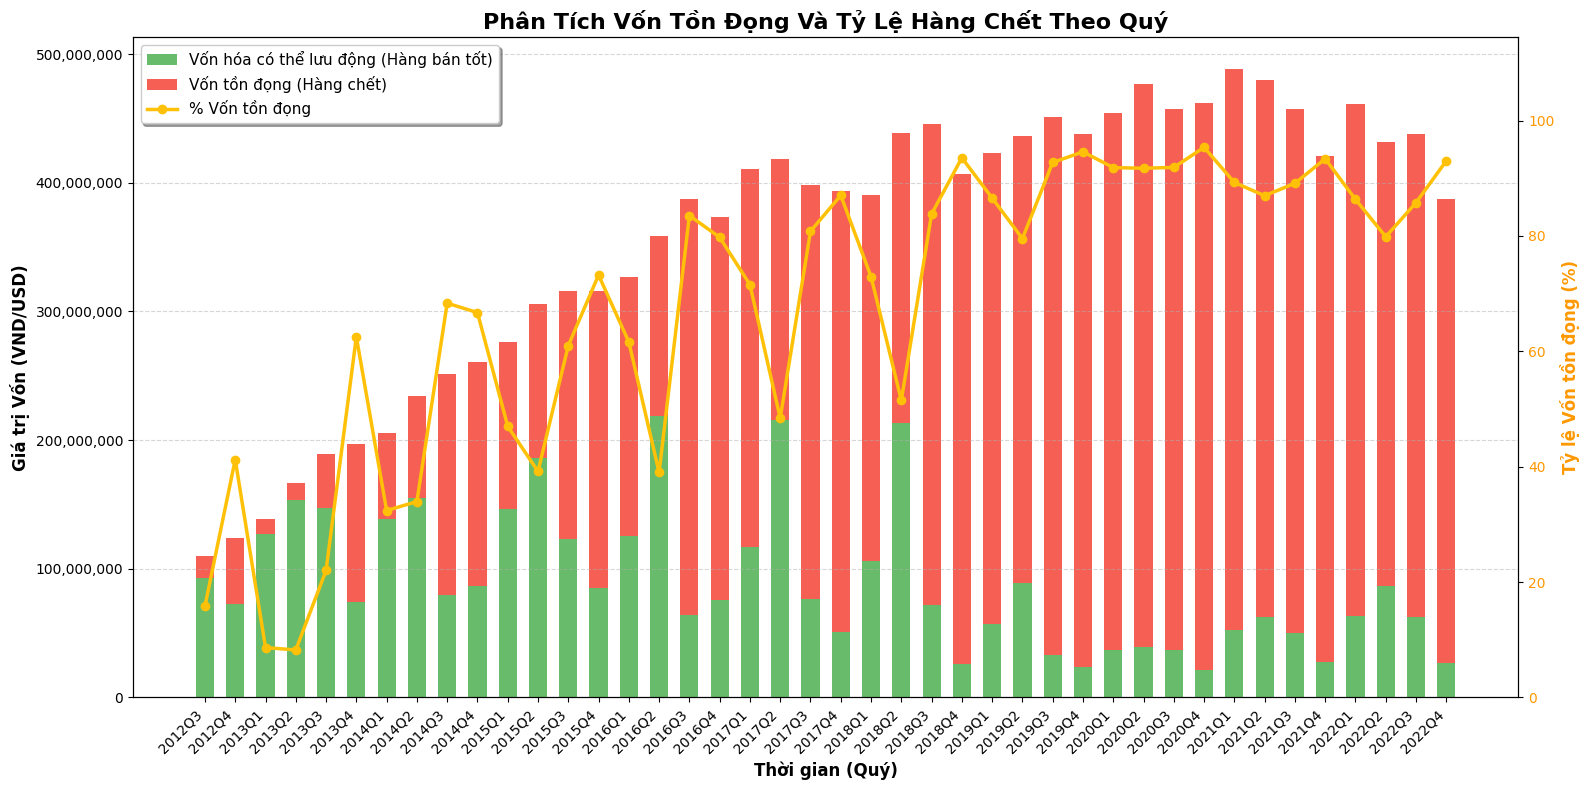

In [51]:
# Chuyển đổi định dạng ngày tháng
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# Tạo cột Quý (Năm-Quý, ví dụ: 2022Q1, 2022Q2)
inventory['Quarter'] = inventory['snapshot_date'].dt.to_period('Q')

# ---------------------------------------------------------
# LƯU Ý NGHIỆP VỤ: Lấy mốc thời gian "Chốt sổ" (End of Quarter)
# Lấy ra ngày chụp tồn kho cuối cùng của mỗi quý để làm đại diện cho Quý đó
# ---------------------------------------------------------
end_of_quarter_dates = inventory.groupby('Quarter')['snapshot_date'].max()
quarterly_inventory = inventory[inventory['snapshot_date'].isin(end_of_quarter_dates)].copy()

# 2. GHÉP BẢNG ĐỂ TÍNH TIỀN VỐN
df = pd.merge(quarterly_inventory, products[['product_id', 'cogs']], on='product_id', how='left')

# Tính tổng vốn cho TỪNG sản phẩm
df['total_capital'] = df['stock_on_hand'] * df['cogs']

# 3. PHÂN LOẠI VỐN
# Cờ quá tải = 1 VÀ tỷ lệ bán ra < 10% (Bạn có thể tinh chỉnh 0.1)
df['is_dead_stock'] = (df['overstock_flag'] == 1) & (df['sell_through_rate'] < 0.1)
df['dead_stock_capital'] = df.apply(lambda x: x['total_capital'] if x['is_dead_stock'] else 0, axis=1)

# 4. GOM NHÓM THEO QUÝ
quarterly_capital = df.groupby('Quarter').agg(
    Total_Inventory_Capital=('total_capital', 'sum'),
    Dead_Stock_Capital=('dead_stock_capital', 'sum')
).reset_index()

# Chuyển Quarter về chuỗi (String) để biểu đồ đọc được dễ dàng
quarterly_capital['Quarter_Str'] = quarterly_capital['Quarter'].astype(str)

# Vốn hóa lưu động (Vốn hiệu quả) = Tổng vốn - Vốn tồn đọng
quarterly_capital['Active_Working_Capital'] = quarterly_capital['Total_Inventory_Capital'] - quarterly_capital['Dead_Stock_Capital']

# Tính phần trăm (%) Vốn tồn đọng trên tổng vốn
quarterly_capital['Pct_Dead_Stock'] = (quarterly_capital['Dead_Stock_Capital'] / quarterly_capital['Total_Inventory_Capital']) * 100

# 5. VẼ BIỂU ĐỒ TRỰC QUAN HOÁ
fig, ax1 = plt.subplots(figsize=(16, 8))

# Trục Y thứ 1: Cột chồng
ax1.bar(quarterly_capital['Quarter_Str'], quarterly_capital['Active_Working_Capital'], 
        label='Vốn hóa có thể lưu động (Hàng bán tốt)', color='#4CAF50', width=0.6, alpha=0.85)

ax1.bar(quarterly_capital['Quarter_Str'], quarterly_capital['Dead_Stock_Capital'], 
        bottom=quarterly_capital['Active_Working_Capital'], 
        label='Vốn tồn đọng (Hàng chết)', color='#F44336', width=0.6, alpha=0.85)

ax1.set_xlabel('Thời gian (Quý)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Giá trị Vốn (VND/USD)', fontsize=12, fontweight='bold')
ax1.set_title('Phân Tích Vốn Tồn Đọng Và Tỷ Lệ Hàng Chết Theo Quý', fontsize=16, fontweight='bold')

# Định dạng số hàng nghìn và xoay nhãn trục X để không bị đè lên nhau
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45, ha='right')

# Trục Y thứ 2: Đường phần trăm
ax2 = ax1.twinx()
ax2.plot(quarterly_capital['Quarter_Str'], quarterly_capital['Pct_Dead_Stock'], 
         color='#FFC107', marker='o', linewidth=2.5, markersize=6, 
         label='% Vốn tồn đọng')

ax2.set_ylabel('Tỷ lệ Vốn tồn đọng (%)', fontsize=12, fontweight='bold', color='#FF9800')
ax2.tick_params(axis='y', labelcolor='#FF9800')
# Chống lỗi nếu tập data bị trống, giới hạn trục y từ 0 đến max + 20% đệm
max_pct = quarterly_capital['Pct_Dead_Stock'].max()
ax2.set_ylim(0, (max_pct * 1.2) if pd.notna(max_pct) and max_pct > 0 else 100)

# Gom chú thích (Legend)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11, frameon=True, shadow=True)

# Lưới (grid)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Màu xanh lá cây: Bất cứ sản phẩm nào không chạm ngưỡng báo động đỏ

Màu đỏ: Là tổng giá trị vốn (stock_on_hand * cogs) của những sản phẩm bị dán cờ dư thừa (overstock_flag = 1) VÀ có tỷ lệ bán ra cực thấp (sell_through_rate < 0.1)

Màu vàng: (Vốn màu Đỏ / Tổng vốn Xanh + Đỏ) * 100

Tổng giá trị tồn kho (cột Xanh + Đỏ) đã tăng phi mã gấp gần 5 lần, từ mức ~100 triệu (năm 2012) lên đỉnh điểm gần 500 triệu vào giai đoạn 2020-2022

Sự tăng trưởng quy mô đi kèm với sự suy giảm nghiêm trọng về chất lượng dòng tiền. Tỷ lệ % Vốn tồn đọng (đường màu vàng) leo dốc từ mức an toàn dưới 20% (năm 2013) lên đến ngưỡng khủng hoảng 80% - 95% trong giai đoạn 2020-2022.

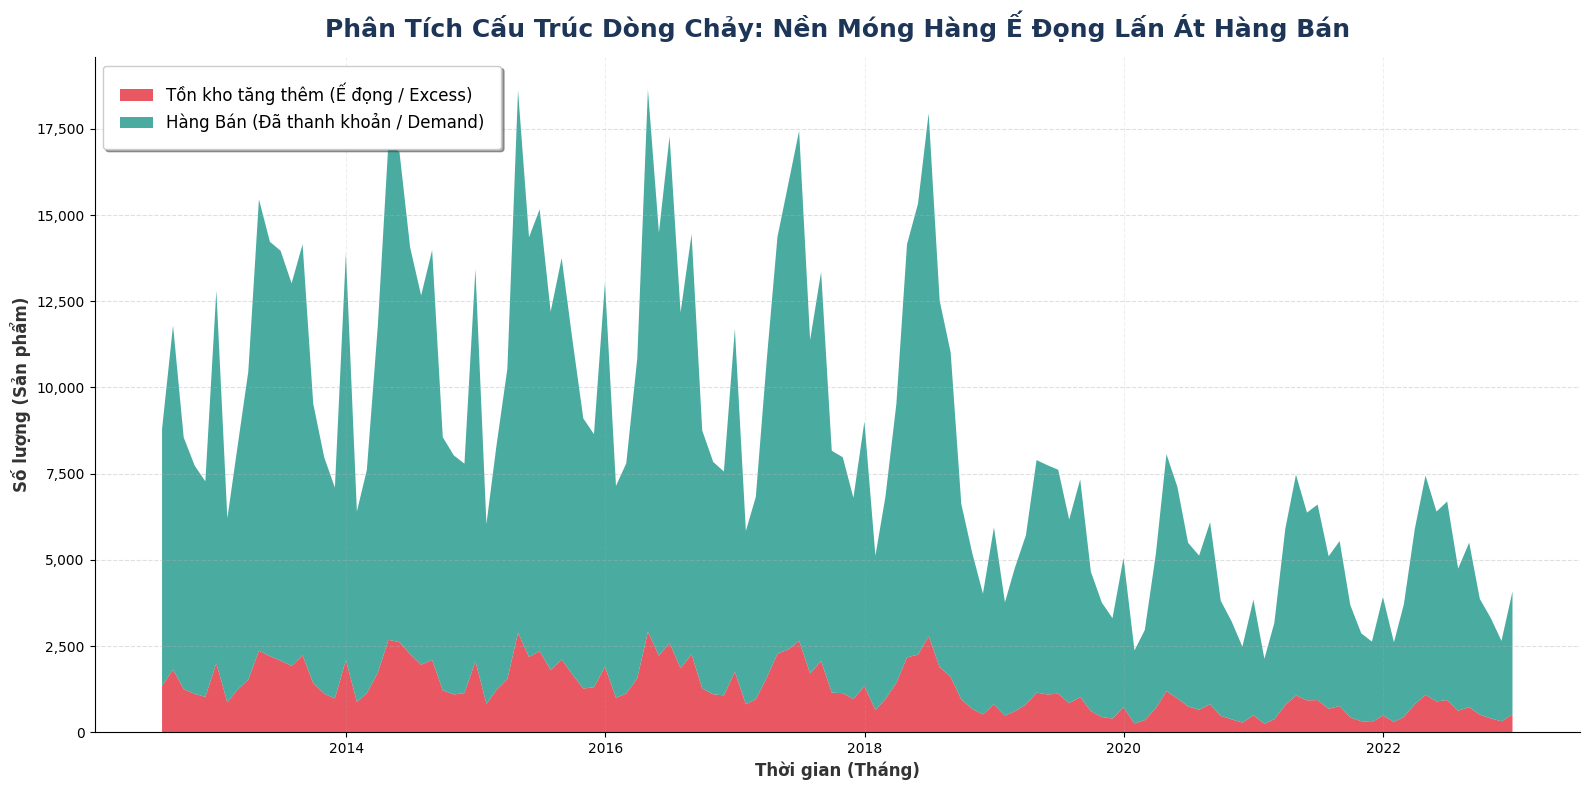

In [52]:
## GỘP CHUNG VỚI GROSS MARGIN hoặc tách ra thành 1 phần tổng thể trước khi vào phần đó

inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# 2. GOM NHÓM DỮ LIỆU THEO THÁNG
monthly_flow = inventory.groupby('snapshot_date').agg(
    Total_Received=('units_received', 'sum'),
    Total_Sold=('units_sold', 'sum')
).reset_index()

# Tính Tồn kho tăng thêm (Net Addition) = Nhập - Bán
monthly_flow['Net_Addition'] = monthly_flow['Total_Received'] - monthly_flow['Total_Sold']

# Sắp xếp theo thời gian
monthly_flow = monthly_flow.sort_values('snapshot_date')

# 3. VẼ BIỂU ĐỒ MIỀN CHỒNG (STACKED AREA CHART)
fig, ax = plt.subplots(figsize=(16, 8))

# ĐỔI THỨ TỰ: Cho Net_Addition (Ế đọng) xuống lớp dưới cùng, Total_Sold (Bán được) lên trên
# ĐỔI MÀU: Sử dụng bảng màu chuyên nghiệp (Crimson Red cho lỗi/ế, Teal Green cho phần bán tốt)
ax.stackplot(monthly_flow['snapshot_date'], 
             monthly_flow['Net_Addition'],   # Lớp đáy (Đỏ)
             monthly_flow['Total_Sold'],     # Lớp trên (Xanh)
             labels=['Tồn kho tăng thêm (Ế đọng / Excess)', 'Hàng Bán (Đã thanh khoản / Demand)'],
             colors=['#E63946', '#2A9D8F'],  # Mã màu hiện đại, đỡ chói hơn
             alpha=0.85)                     # Độ trong suốt dịu mắt

# Định dạng Trục Y và Tiêu đề
ax.set_xlabel('Thời gian (Tháng)', fontsize=12, fontweight='bold', color='#333333')
ax.set_ylabel('Số lượng (Sản phẩm)', fontsize=12, fontweight='bold', color='#333333')
ax.set_title('Phân Tích Cấu Trúc Dòng Chảy: Nền Móng Hàng Ế Đọng Lấn Át Hàng Bán', 
             fontsize=18, fontweight='bold', color='#1D3557', pad=15)

# Định dạng số cho trục Y (thêm dấu phẩy)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Tùy chỉnh chú thích (Legend)
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

# Lưới (grid) tinh tế hơn
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle='--', alpha=0.2)

# Xóa viền trên và viền phải của biểu đồ cho thoáng
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Lượng nhập hàng dư thừa của segment

In [53]:
## Gộp chung vào gross margin luôn

# 1. TÍNH TOÁN VỐN ĐỌNG THEO CATEGORY VÀ SEGMENT
cat_seg_capital = dead_stock_df.groupby(['category', 'segment'])['capital'].sum().reset_index()

# Lọc ra Top 5 Danh mục chiếm nhiều vốn đọng nhất để dễ nhìn
top_categories = cat_seg_capital.groupby('category')['capital'].sum().nlargest(5).index
filtered_data = cat_seg_capital[cat_seg_capital['category'].isin(top_categories)]

# 2. VẼ BIỂU ĐỒ CỘT NHÓM (GROUPED BAR CHART)
plt.figure(figsize=(14, 7))
sns.barplot(data=filtered_data, x='category', y='capital', hue='segment', palette='viridis')

plt.title('Top 5 Danh mục Sản phẩm (Category) Chứa Nhiều Hàng Chết Nhất (Theo Phân Khúc)', fontsize=16, fontweight='bold')
plt.xlabel('Danh mục (Category)', fontsize=12)
plt.ylabel('Vốn Tồn đọng (VND)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.legend(title='Phân khúc (Segment)', fontsize=11)

plt.tight_layout()
plt.show()

# Xác định danh mục tệ nhất để dùng cho Phần 3
worst_category = top_categories[0]
print(f"Danh mục bị ứ đọng nghiêm trọng nhất là: {worst_category}")

NameError: name 'dead_stock_df' is not defined

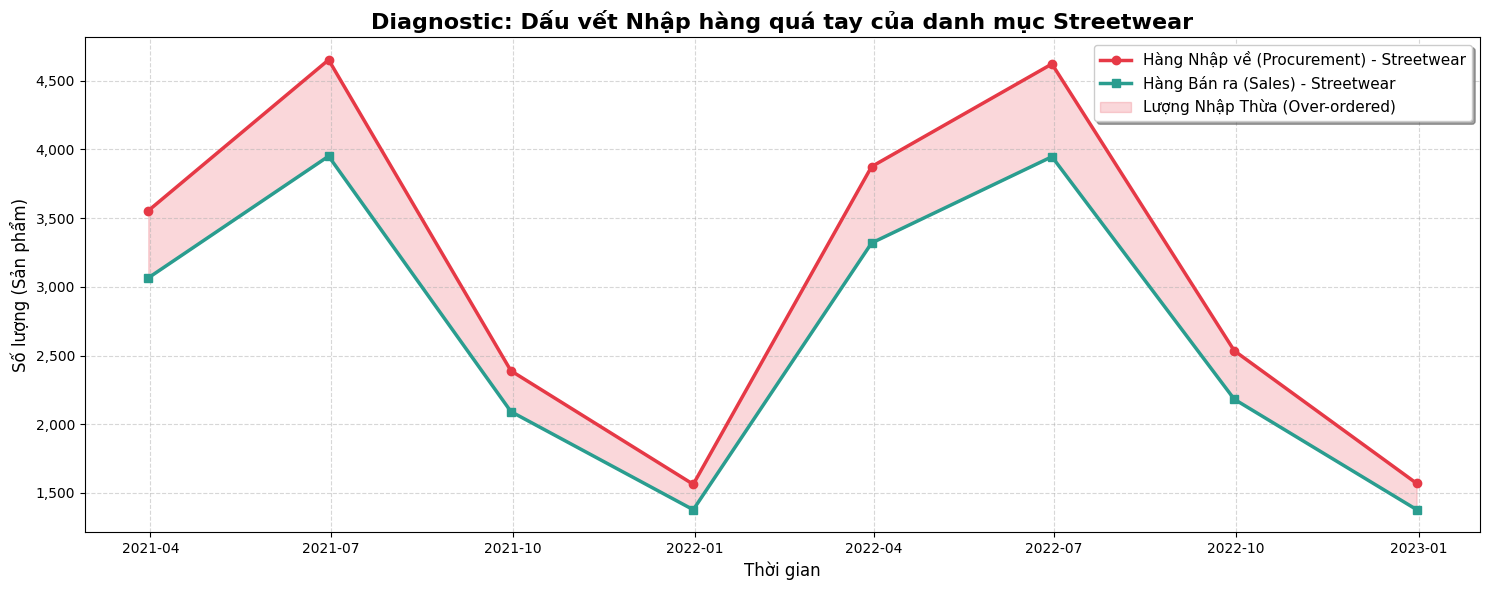

In [ ]:
## HAY
# 1. LỌC LỊCH SỬ CỦA DANH MỤC TỆ NHẤT
# Sử dụng biến worst_category từ phần 2 (ví dụ: 'Outerwear' hoặc 'T-shirt')
# Để biểu đồ dễ đọc, ta chỉ xét lịch sử trong năm 2021 và 2022
history_df = df[(df['category'] == worst_category) & (df['snapshot_date'].dt.year >= 2021)].copy()

# Gom nhóm theo tháng để xem tổng cung cầu của danh mục này
monthly_trend = history_df.groupby('snapshot_date').agg(
    Units_Received=('units_received', 'sum'),
    Units_Sold=('units_sold', 'sum')
).reset_index()

# 2. VẼ BIỂU ĐỒ TRUY VẾT MUA HÀNG VS. SỨC MUA THỰC TẾ
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(monthly_trend['snapshot_date'], monthly_trend['Units_Received'], 
        label=f'Hàng Nhập về (Procurement) - {worst_category}', 
        color='#E63946', marker='o', linewidth=2.5)

ax.plot(monthly_trend['snapshot_date'], monthly_trend['Units_Sold'], 
        label=f'Hàng Bán ra (Sales) - {worst_category}', 
        color='#2A9D8F', marker='s', linewidth=2.5)

# Đổ màu phần chênh lệch (Lượng nhập thừa)
ax.fill_between(monthly_trend['snapshot_date'], 
                monthly_trend['Units_Sold'], 
                monthly_trend['Units_Received'], 
                where=(monthly_trend['Units_Received'] > monthly_trend['Units_Sold']), 
                interpolate=True, color='#E63946', alpha=0.2, label='Lượng Nhập Thừa (Over-ordered)')

ax.set_title(f'Diagnostic: Dấu vết Nhập hàng quá tay của danh mục {worst_category}', fontsize=16, fontweight='bold')
ax.set_xlabel('Thời gian', fontsize=12)
ax.set_ylabel('Số lượng (Sản phẩm)', fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---

### Rủi ro tài chính không thoát được hàng tồn

--------------------------------------------------
🎯 BÁO CÁO THIỆT HẠI DỰ KIẾN NĂM 2023 🎯
Tổng vốn tồn kho hiện tại: 387,629,923 VND
Giá trị bốc hơi do Lão hóa: 315,525,893 VND
Số lượng sản phẩm chiếm chỗ vô ích: 96,941 đơn vị
--------------------------------------------------
Biên lợi nhuận gộp ban đầu (Kỳ vọng): 17.63%
Biên lợi nhuận gộp ĐIỀU CHỈNH (Thực tế): -49.42%
=> Thiệt hại Margin: 67.05%
--------------------------------------------------


--------------------------------------------------
🎯 BÁO CÁO THIỆT HẠI DỰ KIẾN NĂM 2023 🎯
Tổng vốn tồn kho hiện tại: 387,629,923 VND
Giá trị bốc hơi do Lão hóa: 315,525,893 VND
Số lượng sản phẩm chiếm chỗ vô ích: 96,941 đơn vị
--------------------------------------------------
Biên lợi nhuận gộp ban đầu (Kỳ vọng): 17.63%
Biên lợi nhuận gộp ĐIỀU CHỈNH (Thực tế): -49.42%
=> Thiệt hại Margin: 67.05%
--------------------------------------------------


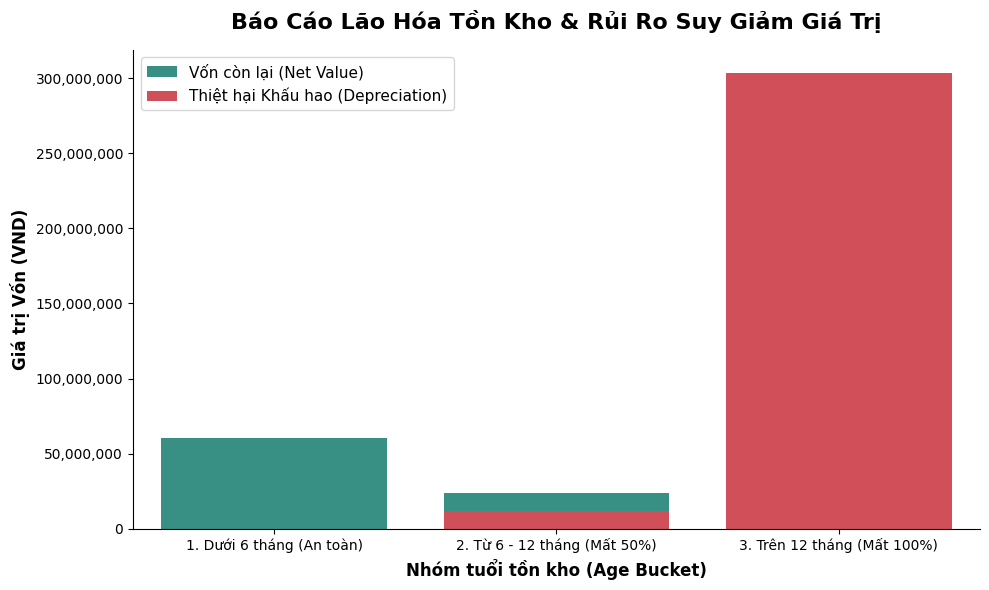

In [ ]:
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# 2. TÍNH TUỔI TỒN KHO (INVENTORY AGING)
# Giả định proxy: Đếm số tháng một sản phẩm nằm trong tình trạng bán chậm (sell_through_rate < 0.1)
stagnant_inventory = inventory[(inventory['sell_through_rate'] < 0.1) & 
                                (inventory['stock_on_hand'] > 0)].copy()

age_df = stagnant_inventory.groupby('product_id')['snapshot_date'].nunique().reset_index()
age_df.rename(columns={'snapshot_date': 'age_in_months'}, inplace=True)

# 3. CHUẨN BỊ DỮ LIỆU THÁNG MỚI NHẤT ĐỂ ĐÁNH GIÁ (VD: Tháng 12/2022)
latest_date = inventory['snapshot_date'].max()
latest_inventory = inventory[inventory['snapshot_date'] == latest_date].copy()

# Ghép tuổi tồn kho vào (nếu không có trong age_df tức là hàng mới, tuổi = 0)
latest_inventory = pd.merge(latest_inventory, age_df, on='product_id', how='left')
latest_inventory['age_in_months'] = latest_inventory['age_in_months'].fillna(0)

# Ghép cogs và price để tính tiền
latest_inventory = pd.merge(latest_inventory, products[['product_id', 'cogs', 'price']], on='product_id', how='left')
latest_inventory['capital'] = latest_inventory['stock_on_hand'] * latest_inventory['cogs']

# 4. ÁP DỤNG LUẬT KHẤU HAO (DEPRECIATION ASSUMPTION)
def calculate_depreciation(row):
    if row['age_in_months'] >= 12:
        return row['capital'] * 1.0  # Mất trắng 100% (Write-off)
    elif row['age_in_months'] >= 6:
        return row['capital'] * 0.5  # Mất 50% giá trị
    else:
        return 0  # Dưới 6 tháng coi như an toàn

latest_inventory['depreciation_loss'] = latest_inventory.apply(calculate_depreciation, axis=1)

# Phân nhóm để vẽ biểu đồ
def age_bucket(months):
    if months >= 12: return '3. Trên 12 tháng (Mất 100%)'
    elif months >= 6: return '2. Từ 6 - 12 tháng (Mất 50%)'
    else: return '1. Dưới 6 tháng (An toàn)'

latest_inventory['age_bucket'] = latest_inventory['age_in_months'].apply(age_bucket)

# 5. KHÁI TOÁN THIỆT HẠI VÀ BIÊN LỢI NHUẬN GỘP
total_capital = latest_inventory['capital'].sum()
total_loss = latest_inventory['depreciation_loss'].sum()
wasted_space_units = latest_inventory[latest_inventory['age_in_months'] >= 6]['stock_on_hand'].sum()

# Giả lập Biên lợi nhuận Gộp (Gross Margin) nếu bán hết đống hàng này
expected_revenue = (latest_inventory['stock_on_hand'] * latest_inventory['price']).sum()
original_gross_profit = expected_revenue - total_capital
original_margin = (original_gross_profit / expected_revenue) * 100

adjusted_gross_profit = original_gross_profit - total_loss
adjusted_margin = (adjusted_gross_profit / expected_revenue) * 100

print("-" * 50)
print("🎯 BÁO CÁO THIỆT HẠI DỰ KIẾN NĂM 2023 🎯")
print(f"Tổng vốn tồn kho hiện tại: {total_capital:,.0f} VND")
print(f"Giá trị bốc hơi do Lão hóa: {total_loss:,.0f} VND")
print(f"Số lượng sản phẩm chiếm chỗ vô ích: {wasted_space_units:,.0f} đơn vị")
print("-" * 50)
print(f"Biên lợi nhuận gộp ban đầu (Kỳ vọng): {original_margin:.2f}%")
print(f"Biên lợi nhuận gộp ĐIỀU CHỈNH (Thực tế): {adjusted_margin:.2f}%")
print(f"=> Thiệt hại Margin: {(original_margin - adjusted_margin):.2f}%")
print("-" * 50)

# 6. VẼ BIỂU ĐỒ TRỰC QUAN HÓA
aging_summary = latest_inventory.groupby('age_bucket').agg(
    Capital=('capital', 'sum'),
    Loss=('depreciation_loss', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ cột chồng: Vốn (Màu xanh) nằm dưới, Phần mất đi (Màu đỏ) nằm đè lên
sns.barplot(data=aging_summary, x='age_bucket', y='Capital', color='#2A9D8F', label='Vốn còn lại (Net Value)')
sns.barplot(data=aging_summary, x='age_bucket', y='Loss', color='#E63946', label='Thiệt hại Khấu hao (Depreciation)')

ax.set_title('Báo Cáo Lão Hóa Tồn Kho & Rủi Ro Suy Giảm Giá Trị', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Nhóm tuổi tồn kho (Age Bucket)', fontsize=12, fontweight='bold')
ax.set_ylabel('Giá trị Vốn (VND)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Xóa viền trên và phải
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# # Load inventory data
# inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# # Aggregate inventory by month (total stock on hand across all products)
# inventory_monthly = inventory.groupby('snapshot_date').agg({
#     'stock_on_hand': 'sum',
#     'units_sold': 'sum',
#     'units_received': 'sum'
# }).reset_index()

# # Line graph for inventory over time
# fig = px.line(
#     inventory_monthly, 
#     x='snapshot_date', 
#     y='stock_on_hand',
#     title='Inventory (Stock on Hand) Over Time',
#     labels={'snapshot_date': 'Date', 'stock_on_hand': 'Stock on Hand'},
#     markers=True
# )
# fig.update_layout(template='plotly_white')
# fig.show()

In [ ]:
## Màu và size bị ế

# inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# # Ghép bảng để lấy thêm thông tin Size, Color, COGS từ products
# df = pd.merge(inventory, products[['product_id', 'size', 'color', 'cogs']], on='product_id', how='left')
# df['capital'] = df['stock_on_hand'] * df['cogs']

# # 2. LỌC DỮ LIỆU THÁNG MỚI NHẤT & XÁC ĐỊNH DEAD STOCK
# latest_date = df['snapshot_date'].max()
# latest_month_df = df[df['snapshot_date'] == latest_date].copy()

# # Định nghĩa Dead Stock: cờ overstock = 1 và bán ra dưới 10%
# dead_stock_df = latest_month_df[(latest_month_df['overstock_flag'] == 1) & 
#                                 (latest_month_df['sell_through_rate'] < 0.1)]

# # 3. PHÂN TÍCH THEO SIZE VÀ COLOR
# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # Biểu đồ 1: Vốn đọng theo Size
# size_capital = dead_stock_df.groupby('size')['capital'].sum().sort_values(ascending=False).reset_index()
# sns.barplot(data=size_capital, x='size', y='capital', ax=axes[0], palette='Reds_r')
# axes[0].set_title('Phân bổ Vốn Tồn đọng (Dead Stock) theo Size', fontsize=14, fontweight='bold')
# axes[0].set_xlabel('Kích cỡ (Size)', fontsize=12)
# axes[0].set_ylabel('Vốn Tồn đọng (VND)', fontsize=12)
# axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# # Biểu đồ 2: Vốn đọng theo Color (Top 10 màu tệ nhất)
# color_capital = dead_stock_df.groupby('color')['capital'].sum().sort_values(ascending=False).head(10).reset_index()
# sns.barplot(data=color_capital, x='capital', y='color', ax=axes[1], palette='Oranges_r')
# axes[1].set_title('Top 10 Màu Sắc Ế Đọng Nhất', fontsize=14, fontweight='bold')
# axes[1].set_xlabel('Vốn Tồn đọng (VND)', fontsize=12)
# axes[1].set_ylabel('Màu sắc (Color)', fontsize=12)
# axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# plt.tight_layout()
# plt.show()

In [ ]:
## KHỐI LƯƠNG XẢ HÀNG QUA KHUYẾN MÃI

# # 2. XỬ LÝ DỮ LIỆU BÁN HÀNG VÀ KHUYẾN MÃI
# orders['order_date'] = pd.to_datetime(orders['order_date'])
# # Đưa order_date về ngày cuối tháng để merge với snapshot_date của inventory
# orders['month_end'] = orders['order_date'] + pd.offsets.MonthEnd(0)

# # Merge chi tiết đơn hàng với thông tin đơn hàng
# sales_df = pd.merge(order_items, orders[['order_id', 'month_end']], on='order_id', how='left')

# # Xác định xem một sản phẩm được bán ra có dùng mã khuyến mãi hay không
# sales_df['is_promo'] = sales_df['promo_id'].notna()

# # Tính tổng số lượng bán bằng khuyến mãi theo từng tháng
# monthly_sales = sales_df.groupby('month_end').agg(
#     Promo_Sold_Qty=('quantity', lambda x: x[sales_df.loc[x.index, 'is_promo']].sum())
# ).reset_index()

# # 3. XỬ LÝ DỮ LIỆU TỒN KHO
# inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
# monthly_inventory = inventory.groupby('snapshot_date').agg(
#     Total_Stock_On_Hand=('stock_on_hand', 'sum')
# ).reset_index()

# # 4. MERGE DỮ LIỆU KHO VÀ KHUYẾN MÃI
# combined_df = pd.merge(monthly_inventory, monthly_sales, left_on='snapshot_date', right_on='month_end', how='inner')

# # 5. VẼ BIỂU ĐỒ TRỰC QUAN HÓA (DUAL-AXIS CHART NHƯNG CÙNG ĐƠN VỊ SỐ LƯỢNG)
# fig, ax1 = plt.subplots(figsize=(16, 8))

# # Trục Y thứ 1: Tổng tồn kho (Đường màu đỏ)
# ax1.plot(combined_df['snapshot_date'], combined_df['Total_Stock_On_Hand'], 
#          color='#E63946', linewidth=3, marker='o', markersize=4, label='Tổng Tồn Kho (Stock on Hand)')

# ax1.set_xlabel('Thời gian (Tháng)', fontsize=12, fontweight='bold', color='#333333')
# ax1.set_ylabel('Số lượng Tồn kho (Sản phẩm)', fontsize=12, fontweight='bold', color='#E63946')
# ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
# ax1.tick_params(axis='y', labelcolor='#E63946')

# # Trục Y thứ 2: Số lượng bán bằng Khuyến mãi (Biểu đồ cột mờ phía dưới)
# ax2 = ax1.twinx()
# ax2.bar(combined_df['snapshot_date'], combined_df['Promo_Sold_Qty'], 
#         width=20, color='#2A9D8F', alpha=0.5, label='Số lượng Bán bằng Khuyến mãi (Promo Sales)')

# ax2.set_ylabel('Số lượng Bán bằng Khuyến mãi', fontsize=12, fontweight='bold', color='#2A9D8F')
# ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
# ax2.tick_params(axis='y', labelcolor='#2A9D8F')

# # Mẹo hiển thị: Đẩy giới hạn trục Y2 lên gấp đôi max để cột mờ không đè lên đường line phía trên
# ax2.set_ylim(0, max(combined_df['Promo_Sold_Qty']) * 2.5) 

# # Tiêu đề và Legend
# plt.title('Diagnostic: Khối Lượng Hàng Xả Qua Khuyến Mãi Có Đang "Cứu Cánh" Cho Kho?', 
#           fontsize=16, fontweight='bold', color='#1D3557', pad=15)

# lines_1, labels_1 = ax1.get_legend_handles_labels()
# lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11, frameon=True, shadow=True)

# ax1.grid(axis='both', linestyle='--', alpha=0.3)
# ax1.spines['top'].set_visible(False)
# ax2.spines['top'].set_visible(False)

# plt.tight_layout()
# plt.show()